## Dealing with the coloring problem
- Playing with jupyter notebooks to finetune code later in the main file ('idk.py').
- Specifically the '*2.json' file not the level 3 one.

In [1]:
import geopandas as gpd

kenya = gpd.read_file("./data/gadm41_KEN_2.json")
nrb_df = kenya[kenya["NAME_1"] == "Nairobi"]

# nrb_df.shape

# Reseting the index of the df
nrb_df = nrb_df.reset_index(drop=True) 

print(nrb_df["NAME_2"])

0      DagorettiNorth
1      DagorettiSouth
2     EmbakasiCentral
3        EmbakasiEast
4       EmbakasiNorth
5       EmbakasiSouth
6        EmbakasiWest
7           Kamukunji
8            Kasarani
9               Kibra
10            Langata
11           Makadara
12            Mathare
13           Roysambu
14            Ruaraka
15            Starehe
16          Westlands
Name: NAME_2, dtype: str


In [2]:
# Finding the Neighbours
# Don't know fs if it's BFS or DFS
# It's actually an Adjacency list - a dictionary of lists for each sub-county LOL😅
neighbors = {}

for i, row in nrb_df.iterrows():
    neighbors[i] = []

    for j, other in nrb_df.iterrows():
        if i != j and row.geometry.intersects(other.geometry):
            neighbors[i].append(j)

In [3]:
# Creating the secondary graph
import networkx as nx

G = nx.Graph()

# Add nodes
for i in range(len(nrb_df)):
    G.add_node(i)

# Add edges
for i, nbrs in neighbors.items():
    for j in nbrs:
        G.add_edge(i, j)

In [4]:
# Graph colouring
# colors = nx.coloring.greedy_color(G, strategy="largest_first")

colors = nx.coloring.greedy_color(G, strategy="DSATUR")

colors.values()

dict_values([0, 1, 2, 3, 0, 1, 2, 1, 3, 3, 2, 1, 0, 1, 0, 3, 2])

In [5]:
#Attaching the colors to the original dataframe
nrb_df["color"] = nrb_df.index.map(colors)

In [ ]:
# Mapping with another colour scheme - just for preference maybe
color_map = {
    0: "#4CAF50",  # green
    1: "#2196F3",  # blue
    2: "#FF9800",  # orange
    3: "#E91E63",  # pink
}

nrb_df["color"] = nrb_df["color"].map(color_map)

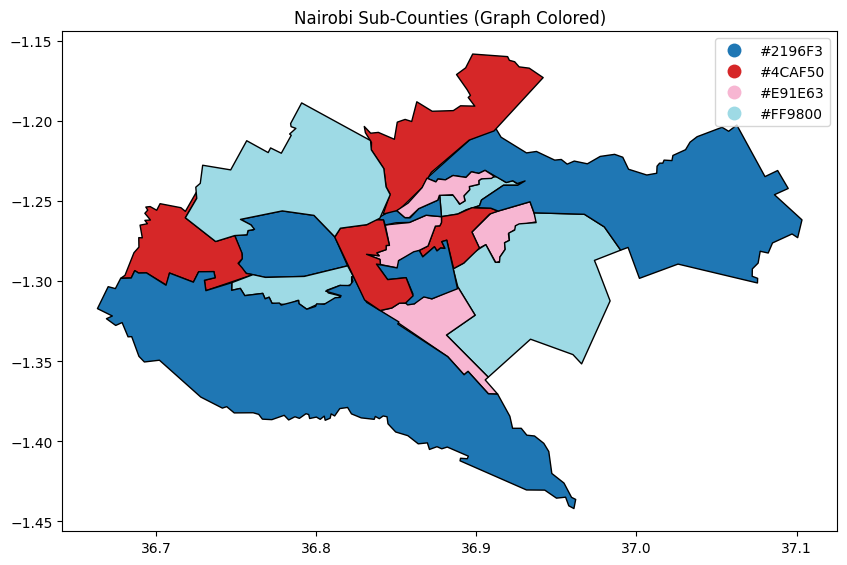

In [7]:
# Final plotting
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

nrb_df.plot(
    column="color",
    cmap="tab20",  # nice categorical colors
    edgecolor="black",
    legend=True,
    ax=ax
)

plt.title("Nairobi Sub-Counties (Graph Colored)")
plt.show()